# Native (cos $\theta$, sin $\theta$) Basis Analysis — Perturbation-Agnostic Symbolic Recovery

This notebook performs symbolic regression on the `delta_V_net` output using the network's
**native input coordinates** `(cos φ, sin φ)` instead of converting to θ_phys first.

**Key insight**: The encoder-decoder learns an arbitrary angle convention φ. Previous
notebooks (4, 5) calibrated a phase offset φ → θ_phys before running symbolic regression.
This calibration introduces systematic error that corrupts recovered coefficients.

**This notebook's approach**: Perform all regression directly on `(cos φ, sin φ)` — the
actual inputs to `delta_V_net`. This:
- **Eliminates phase calibration error** from the regression step
- **Matches the NN's representational capacity** (functions of cos/sin, not θ)
- **Naturally handles trig perturbations** (they're exact polynomials in cos/sin)
- Works for polynomial perturbations too (the NN learns a cos/sin approximation)

Phase calibration is used ONLY for ground-truth comparison, not for regression.

**Methods applied**:
1. **SINDy** with 2D polynomial library on (cos_q, sin_q)
2. **ARD** (Automatic Relevance Determination / Sparse Bayesian Learning)
3. **PySR** with 2D input (cos_q, sin_q)

In [1]:
# Standard library imports
import os, sys
VENV_PATH = "/Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/.venv/lib/python3.9/site-packages"
if VENV_PATH not in sys.path:
    sys.path.append(VENV_PATH)

# Auto-detect project root
_cwd = os.path.abspath('')
PROJECT_ROOT = _cwd
for _ in range(5):
    if os.path.isdir(os.path.join(PROJECT_ROOT, 'examples')):
        break
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pytorch_lightning import seed_everything
from pysr import PySRRegressor
import pysindy as ps
from sklearn.linear_model import ARDRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Import BOTH model classes
from examples.pend_lag_cavae_trainer import Model
from examples.pend_delta_v_frozen_trainer import DeltaVFrozenModel

seed_everything(0)
%matplotlib inline

Project root: /Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main


/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pytorch_lightning/loggers/tensorboard.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Configuration

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# Checkpoints
CKPT_UNPERTURBED = 'pend-lag-cavae-T_p=4-epoch=983-step=7871.ckpt'
CKPT_DELTA_V     = 'pend-delta-v-frozen-epoch=845.ckpt'

# Ground-truth perturbation coefficients
ETA1, ETA2, ETA3 = -0.0481, 0.0113, 0.1125
M_TRUE, L_TRUE = 1.0, 1.0
ALPHA1 = 3 * ETA1 / (M_TRUE * L_TRUE**2)   # -0.1443
ALPHA2 = 3 * ETA2 / (M_TRUE * L_TRUE**2)   #  0.0339
ALPHA3 = 3 * ETA3 / (M_TRUE * L_TRUE**2)   #  0.3375

# Sampling
N_SAMPLES = 500
THETA_MIN, THETA_MAX = 0, 2 * np.pi

# PySR hyperparameters
PYSR_NITERATIONS = 100
PYSR_MAXSIZE     = 25

# Plot settings
DPI = 600

print(f"True perturbation: da = {-ALPHA1:.4f}*theta + {-ALPHA2:.4f}*theta^2 + {-ALPHA3:.4f}*theta^3")
print(f"  alpha1 = {ALPHA1:.4f}, alpha2 = {ALPHA2:.4f}, alpha3 = {ALPHA3:.4f}")

True perturbation: da = 0.1443*theta + -0.0339*theta^2 + -0.3375*theta^3
  alpha1 = -0.1443, alpha2 = 0.0339, alpha3 = 0.3375


## 1. Load Models

Load the unperturbed base model (for phase offset calibration) and the Delta-V model.

In [3]:
ckpt_dir = os.path.join(PROJECT_ROOT, 'results', 'pend')

# Load unperturbed model (for calibration)
model_unpert = Model.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_UNPERTURBED), map_location='cpu')
model_unpert.eval()
print("Unperturbed model loaded.")

# Load Delta-V model — patch torch.load for weights_only compatibility
_orig_torch_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _orig_torch_load(*args, **kwargs)
torch.load = _patched_load

model_delta_v = DeltaVFrozenModel.load_from_checkpoint(
    os.path.join(ckpt_dir, CKPT_DELTA_V), map_location='cpu')
model_delta_v.eval()
torch.load = _orig_torch_load  # restore

n_params = sum(p.numel() for p in model_delta_v.ode.delta_V_net.parameters())
print(f"Delta-V model loaded. delta_V_net parameters: {n_params}")

Unperturbed model loaded.
Delta-V model loaded. delta_V_net parameters: 2751


## 2. Helper Functions

In [4]:
def extract_native_delta_v(model, theta_np):
    # Extract delta_V_net output in the NN's native (cos, sin) input space.
    # Returns cos_q, sin_q (the regression inputs) and delta_V, delta_a (the targets).
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)

    delta_V = model.ode.delta_V_net(cos_sin)
    V_base = model.ode.V_net(cos_sin)
    M = model.ode.M_net(cos_sin)
    M_flat = M.squeeze()
    V_total = V_base + delta_V

    dV_total = torch.autograd.grad(V_total.sum(), theta, retain_graph=True, create_graph=False)[0]
    d_delta_V = torch.autograd.grad(delta_V.sum(), theta, create_graph=False)[0]

    delta_acc = -(1.0 / M_flat) * d_delta_V
    total_acc = -(1.0 / M_flat) * dV_total

    return {
        'theta':     theta_np,
        'cos_q':     cos_q.detach().numpy(),
        'sin_q':     sin_q.detach().numpy(),
        'delta_V':   delta_V.detach().numpy().flatten(),
        'd_delta_V': d_delta_V.detach().numpy().flatten(),
        'delta_acc': delta_acc.detach().numpy().flatten(),
        'V_base':    V_base.detach().numpy().flatten(),
        'V_total':   V_total.detach().numpy().flatten(),
        'total_acc': total_acc.detach().numpy().flatten(),
        'M':         M_flat.detach().numpy().flatten(),
    }


def extract_base_physics(model, theta_np):
    # Extract V, M, acc from the base (unperturbed) model.
    theta = torch.tensor(theta_np, dtype=torch.float32, requires_grad=True)
    cos_q = torch.cos(theta)
    sin_q = torch.sin(theta)
    cos_sin = torch.stack((cos_q, sin_q), dim=1)
    V = model.ode.V_net(cos_sin)
    M = model.ode.M_net(cos_sin)
    dV = torch.autograd.grad(V.sum(), theta, create_graph=False)[0]
    M_flat = M.squeeze()
    acc = -(1.0 / M_flat) * dV
    return {
        'theta': theta_np,
        'V':   V.detach().numpy().flatten(),
        'M':   M_flat.detach().numpy().flatten(),
        'acc': acc.detach().numpy().flatten(),
    }


def calibrate_phase_offset(phi, a_unpert, g=10.0, l=1.0):
    # Find phase offset between NN angle phi and physical angle theta_phys.
    # NOTE: Used ONLY for ground-truth comparison, NOT for regression.
    K = 3 * g / (2 * l)
    best = None
    for s in [1.0, -1.0]:
        for off0 in np.linspace(0, 2*np.pi, 40):
            res = minimize(
                lambda o: np.mean((a_unpert - (-K * np.sin(s * (phi + o[0]))))**2),
                [off0], method='Nelder-Mead'
            )
            if best is None or res.fun < best[0]:
                best = (res.fun, s, res.x[0])
    mse, sign, offset = best
    return {'offset': offset, 'sign': sign, 'mse': mse}


def phi_to_theta_phys(phi, calib):
    # Convert NN angle phi to physical angle theta_phys in [-pi, pi].
    theta = calib['sign'] * (phi + calib['offset'])
    return ((theta + np.pi) % (2 * np.pi)) - np.pi


print("Helper functions defined.")

Helper functions defined.


## 3. Extract Data in Native Space

Sample $\phi$ values, extract `delta_V_net` output in native $(cos\phi, sin\phi)$ coordinates.
Phase calibration is computed **ONLY** for ground-truth comparison.

In [5]:
theta_range = np.linspace(THETA_MIN, THETA_MAX, N_SAMPLES)

# Extract base physics (for calibration only)
phys_unpert = extract_base_physics(model_unpert, theta_range)

# Phase calibration — for ground truth comparison ONLY
calib = calibrate_phase_offset(theta_range, phys_unpert['acc'])
print("Phase calibration (for ground-truth comparison only):")
print(f"  sign = {calib['sign']:+.0f}, offset = {calib['offset']:.4f} rad, MSE = {calib['mse']:.4f}")

theta_phys = phi_to_theta_phys(theta_range, calib)

# Extract delta-V physics in native space
data = extract_native_delta_v(model_delta_v, theta_range)

# ============================================================
# NATIVE COORDINATES — these are the regression inputs
# ============================================================
cos_q = data['cos_q']
sin_q = data['sin_q']
X_native = np.column_stack([cos_q, sin_q])  # shape (N, 2)

# Regression targets
delta_V = data['delta_V']
delta_a = data['delta_acc']
M_vals = data['M']
M_scale = np.mean(M_vals)

# Ground truth (evaluated at calibrated theta_phys — for comparison only)
true_delta_a = -ALPHA1 * theta_phys - ALPHA2 * theta_phys**2 - ALPHA3 * theta_phys**3
true_delta_V_raw = M_scale * (
    (ALPHA1/2) * theta_phys**2 +
    (ALPHA2/3) * theta_phys**3 +
    (ALPHA3/4) * theta_phys**4
)
true_delta_V = true_delta_V_raw - true_delta_V_raw[0]

# Sort by theta_phys for plotting
sort_idx = np.argsort(theta_phys)
theta_phys_sorted = theta_phys[sort_idx]

print(f"\nNative input space: X_native shape = {X_native.shape}")
print(f"  cos_q range: [{cos_q.min():.3f}, {cos_q.max():.3f}]")
print(f"  sin_q range: [{sin_q.min():.3f}, {sin_q.max():.3f}]")
print(f"  delta_V range: [{delta_V.min():.4f}, {delta_V.max():.4f}]")
print(f"  delta_a range: [{delta_a.min():.4f}, {delta_a.max():.4f}]")
print(f"  M_scale: {M_scale:.4f}")

# R2 of raw NN output vs ground truth
r2_dv_raw = r2_score(true_delta_V[sort_idx], delta_V[sort_idx])
r2_da_raw = r2_score(true_delta_a[sort_idx], delta_a[sort_idx])
print(f"\nRaw NN output vs ground truth:")
print(f"  R2(delta_V_net vs true dV) = {r2_dv_raw:.4f}")
print(f"  R2(delta_a vs true da)     = {r2_da_raw:.4f}")

Phase calibration (for ground-truth comparison only):
  sign = +1, offset = 2.2050 rad, MSE = 0.6618

Native input space: X_native shape = (500, 2)
  cos_q range: [-1.000, 1.000]
  sin_q range: [-1.000, 1.000]
  delta_V range: [-9.0346, -3.2290]
  delta_a range: [-8.5913, 13.3730]
  M_scale: 0.6915

Raw NN output vs ground truth:
  R2(delta_V_net vs true dV) = -26.7930
  R2(delta_a vs true da)     = 0.8225


## 4. Overview: Delta-V Network Output

Visualize the raw `delta_V_net` signal in both $\theta_{\mathrm{phys}}$ space (for comparison
with ground truth) and in the native $(cos\phi, sin\phi)$ space (the regression input).

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=DPI)

# Top left: delta_V vs theta_phys
ax = axes[0, 0]
ax.plot(theta_phys_sorted, delta_V[sort_idx], 'b-', lw=2, label='delta_V_net')
ax.plot(theta_phys_sorted, true_delta_V[sort_idx], 'r--', lw=2, label='True dV')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('Perturbation Potential')
ax.legend()
ax.grid(True, alpha=0.3)

# Top right: delta_a vs theta_phys
ax = axes[0, 1]
ax.plot(theta_phys_sorted, delta_a[sort_idx], 'b-', lw=2, label='delta_a')
ax.plot(theta_phys_sorted, true_delta_a[sort_idx], 'r--', lw=2, label='True da')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('Perturbation Acceleration')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom left: delta_V in native (cos, sin) space
ax = axes[1, 0]
sc = ax.scatter(cos_q, sin_q, c=delta_V, cmap='RdBu_r', s=8)
plt.colorbar(sc, ax=ax, label=r'$\Delta V$')
ax.set_xlabel(r'$\cos\phi$', fontsize=14)
ax.set_ylabel(r'$\sin\phi$', fontsize=14)
ax.set_title('delta_V_net in Native (cos, sin) Space')
ax.set_aspect('equal')

# Bottom right: delta_a in native (cos, sin) space
ax = axes[1, 1]
sc = ax.scatter(cos_q, sin_q, c=delta_a, cmap='RdBu_r', s=8)
plt.colorbar(sc, ax=ax, label=r'$\Delta a$')
ax.set_xlabel(r'$\cos\phi$', fontsize=14)
ax.set_ylabel(r'$\sin\phi$', fontsize=14)
ax.set_title('delta_a in Native (cos, sin) Space')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 5. Method 1: SINDy with 2D Polynomial Library on $(cos\phi, sin\phi)$

Instead of fitting polynomials in $\theta_{\mathrm{phys}}$, we use a **2D polynomial library**
in the network's native input space: `(cos_q, sin_q)`.

**Basis functions**: $1,\; \cos\phi,\; \sin\phi,\; \cos^2\!\phi,\; \cos\phi\cdot\sin\phi,\; \sin^2\!\phi,\; \cos^3\!\phi,\; \ldots$

This eliminates phase calibration from the regression entirely and
naturally handles trigonometric perturbations (which are exact polynomials
in $\cos$ and $\sin$).

In [11]:
print("=" * 65)
print("SINDy (2D POLYNOMIAL) ON NATIVE (cos, sin) COORDINATES")
print("=" * 65)

# --- 5a. SINDy on delta_a ---
print("\n--- 5a. da (from delta_V_net) ---")

y_da = delta_a.reshape(-1, 1)
thresholds = np.logspace(-3, 0, 20)

sindy_da_results = []
for thr in thresholds:
    poly_lib = ps.PolynomialLibrary(degree=5, include_bias=True)
    optimizer = ps.STLSQ(threshold=thr, alpha=1e-5, max_iter=50)
    model = ps.SINDy(feature_library=poly_lib, optimizer=optimizer)
    model.fit(X_native, t=1, x_dot=y_da, feature_names=['cos_q', 'sin_q'])

    pred = model.predict(X_native)
    coef = model.coefficients().flatten()
    n_active = np.sum(np.abs(coef) > 1e-10)
    ss_res = np.sum((y_da - pred)**2)
    ss_tot = np.sum((y_da - y_da.mean())**2)
    r2 = 1 - ss_res / ss_tot

    sindy_da_results.append({
        'threshold': thr, 'n_active': n_active, 'r2': r2,
        'coef': coef.copy(), 'names': model.get_feature_names(),
        'model': model, 'equations': model.equations(),
    })

# Select best: high R2 with limited active terms
candidates = [r for r in sindy_da_results if r['n_active'] <= 6 and r['r2'] > 0.5]
if not candidates:
    candidates = sindy_da_results
best_sindy_da = max(candidates, key=lambda r: r['r2'])

# Compute prediction from best model
pred_da_sindy = np.array(best_sindy_da['model'].predict(X_native)).flatten()

print(f"\nBest SINDy (da): R2 = {best_sindy_da['r2']:.6f}, "
      f"{best_sindy_da['n_active']} active terms, thr = {best_sindy_da['threshold']:.4f}")
print(f"  Equation: {best_sindy_da['equations']}")

print(f"\n  {'Feature':<25s} {'Coefficient':>12s}")
print(f"  {'-'*39}")
for name, c in zip(best_sindy_da['names'], best_sindy_da['coef']):
    if abs(c) > 1e-10:
        print(f"  {name:<25s} {c:>12.6f}")

SINDy (2D POLYNOMIAL) ON NATIVE (cos, sin) COORDINATES

--- 5a. da (from delta_V_net) ---

Best SINDy (da): R2 = 0.773234, 21 active terms, thr = 0.0010
  Equation: ['-0.798 1 + -1.281 cos_q + 0.199 sin_q + -1.752 cos_q^2 + -0.587 cos_q sin_q + 0.954 sin_q^2 + -2.742 cos_q^3 + -1.839 cos_q^2 sin_q + 1.461 cos_q sin_q^2 + 2.038 sin_q^3 + 0.613 cos_q^4 + -6.195 cos_q^3 sin_q + -2.365 cos_q^2 sin_q^2 + 5.608 cos_q sin_q^3 + 3.319 sin_q^4 + 2.655 cos_q^5 + -1.867 cos_q^4 sin_q + -5.397 cos_q^3 sin_q^2 + 0.028 cos_q^2 sin_q^3 + 6.859 cos_q sin_q^4 + 2.011 sin_q^5']

  Feature                    Coefficient
  ---------------------------------------
  1                            -0.798150
  cos_q                        -1.280730
  sin_q                         0.198944
  cos_q^2                      -1.751955
  cos_q sin_q                  -0.586821
  sin_q^2                       0.953808
  cos_q^3                      -2.742101
  cos_q^2 sin_q                -1.839448
  cos_q sin_q^2      

In [12]:
# --- 5b. SINDy on delta_V ---
print("\n--- 5b. dV (from delta_V_net) ---")

y_dv = delta_V.reshape(-1, 1)

sindy_dv_results = []
for thr in thresholds:
    poly_lib = ps.PolynomialLibrary(degree=6, include_bias=True)
    optimizer = ps.STLSQ(threshold=thr, alpha=1e-5, max_iter=50)
    model = ps.SINDy(feature_library=poly_lib, optimizer=optimizer)
    model.fit(X_native, t=1, x_dot=y_dv, feature_names=['cos_q', 'sin_q'])

    pred = model.predict(X_native)
    coef = model.coefficients().flatten()
    n_active = np.sum(np.abs(coef) > 1e-10)
    ss_res = np.sum((y_dv - pred)**2)
    ss_tot = np.sum((y_dv - y_dv.mean())**2)
    r2 = 1 - ss_res / ss_tot

    sindy_dv_results.append({
        'threshold': thr, 'n_active': n_active, 'r2': r2,
        'coef': coef.copy(), 'names': model.get_feature_names(),
        'model': model, 'equations': model.equations(),
    })

candidates = [r for r in sindy_dv_results if r['n_active'] <= 7 and r['r2'] > 0.5]
if not candidates:
    candidates = sindy_dv_results
best_sindy_dv = max(candidates, key=lambda r: r['r2'])

pred_dv_sindy = np.array(best_sindy_dv['model'].predict(X_native)).flatten()

print(f"\nBest SINDy (dV): R2 = {best_sindy_dv['r2']:.6f}, "
      f"{best_sindy_dv['n_active']} active terms, thr = {best_sindy_dv['threshold']:.4f}")
print(f"  Equation: {best_sindy_dv['equations']}")

print(f"\n  {'Feature':<25s} {'Coefficient':>12s}")
print(f"  {'-'*39}")
for name, c in zip(best_sindy_dv['names'], best_sindy_dv['coef']):
    if abs(c) > 1e-10:
        print(f"  {name:<25s} {c:>12.6f}")


--- 5b. dV (from delta_V_net) ---

Best SINDy (dV): R2 = 0.993292, 24 active terms, thr = 0.2336
  Equation: ['-4.094 1 + 1.146 cos_q + 0.844 sin_q + -2.363 cos_q^2 + 1.395 cos_q sin_q + -1.731 sin_q^2 + 0.566 cos_q^2 sin_q + 1.241 cos_q sin_q^2 + 0.278 sin_q^3 + -1.370 cos_q^4 + 0.417 cos_q^3 sin_q + -0.992 cos_q^2 sin_q^2 + 0.978 cos_q sin_q^3 + -0.739 sin_q^4 + -0.435 cos_q^4 sin_q + 0.618 cos_q^3 sin_q^2 + 1.001 cos_q^2 sin_q^3 + 0.623 cos_q sin_q^4 + -0.723 sin_q^5 + -0.936 cos_q^5 sin_q + -1.372 cos_q^4 sin_q^2 + 1.353 cos_q^3 sin_q^3 + -0.375 cos_q sin_q^5 + -1.118 sin_q^6']

  Feature                    Coefficient
  ---------------------------------------
  1                            -4.093685
  cos_q                         1.146355
  sin_q                         0.843531
  cos_q^2                      -2.362724
  cos_q sin_q                   1.395077
  sin_q^2                      -1.730961
  cos_q^2 sin_q                 0.565885
  cos_q sin_q^2                 1.24139

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10), dpi=DPI)

# --- Row 1: delta_a ---
# (a) Threshold scan
ax = axes[0, 0]
ax.semilogx([r['threshold'] for r in sindy_da_results],
            [r['r2'] for r in sindy_da_results], 'o-', color='steelblue')
ax.axvline(best_sindy_da['threshold'], color='red', ls='--', alpha=0.7)
ax.set_xlabel('STLSQ Threshold')
ax.set_ylabel('R2')
ax2 = ax.twinx()
ax2.semilogx([r['threshold'] for r in sindy_da_results],
             [r['n_active'] for r in sindy_da_results], '^-', color='orange', alpha=0.7)
ax2.set_ylabel('N active', color='orange')
ax.set_title('(a) da: Threshold Scan')

# (b) Fit vs data
ax = axes[0, 1]
ax.plot(theta_phys_sorted, delta_a[sort_idx], 'b-', lw=2, label='delta_a (NN)')
ax.plot(theta_phys_sorted, pred_da_sindy[sort_idx], 'r--', lw=2, label='SINDy fit')
ax.plot(theta_phys_sorted, true_delta_a[sort_idx], 'g:', lw=2, label='True da')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_title(f'(b) da: SINDy Fit (R2={best_sindy_da["r2"]:.4f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (c) Residual
ax = axes[0, 2]
ax.plot(theta_phys_sorted, (delta_a - pred_da_sindy)[sort_idx], 'k-', lw=1.5, label='NN - SINDy')
ax.plot(theta_phys_sorted, (delta_a[sort_idx] - true_delta_a[sort_idx]), 'm--', lw=1.5, label='NN - True')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_title('(c) da Residuals')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Row 2: delta_V ---
ax = axes[1, 0]
ax.semilogx([r['threshold'] for r in sindy_dv_results],
            [r['r2'] for r in sindy_dv_results], 'o-', color='steelblue')
ax.axvline(best_sindy_dv['threshold'], color='red', ls='--', alpha=0.7)
ax.set_xlabel('STLSQ Threshold')
ax.set_ylabel('R2')
ax2 = ax.twinx()
ax2.semilogx([r['threshold'] for r in sindy_dv_results],
             [r['n_active'] for r in sindy_dv_results], '^-', color='orange', alpha=0.7)
ax2.set_ylabel('N active', color='orange')
ax.set_title('(d) dV: Threshold Scan')

ax = axes[1, 1]
ax.plot(theta_phys_sorted, delta_V[sort_idx], 'b-', lw=2, label='delta_V_net')
ax.plot(theta_phys_sorted, pred_dv_sindy[sort_idx], 'r--', lw=2, label='SINDy fit')
ax.plot(theta_phys_sorted, true_delta_V[sort_idx], 'g:', lw=2, label='True dV')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_title(f'(e) dV: SINDy Fit (R2={best_sindy_dv["r2"]:.4f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(theta_phys_sorted, (delta_V - pred_dv_sindy)[sort_idx], 'k-', lw=1.5, label='NN - SINDy')
ax.plot(theta_phys_sorted, (delta_V[sort_idx] - true_delta_V[sort_idx]), 'm--', lw=1.5, label='NN - True')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_title('(f) dV Residuals')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('SINDy: 2D Polynomial in Native (cos, sin) Space', fontsize=14)
plt.tight_layout()
plt.show()

# R2 against ground truth
r2_sindy_da_vs_gt = r2_score(true_delta_a, pred_da_sindy)
r2_sindy_dv_vs_gt = r2_score(true_delta_V, pred_dv_sindy)
print(f"SINDy fit vs Ground Truth:")
print(f"  da: R2 = {r2_sindy_da_vs_gt:.6f}")
print(f"  dV: R2 = {r2_sindy_dv_vs_gt:.6f}")

SINDy fit vs Ground Truth:
  da: R2 = 0.650250
  dV: R2 = -26.799138


### 5c. SINDy Symbolic Coefficient Summary

Detailed coefficient tables for best SINDy fits, with ground-truth comparison
evaluated by converting recovered (cos, sin) expressions back to θ_phys.

In [ ]:
# ============================================================
# SINDy Symbolic Output — Coefficient Tables
# ============================================================
print("=" * 70)
print("  SINDy SYMBOLIC COEFFICIENT TABLES (Native Basis)")
print("=" * 70)

# --- da ---
print("\n--- SINDy: delta_a ---")
print(f"  R² (fit to NN):  {best_sindy_da['r2']:.6f}")
r2_da_gt = r2_score(true_delta_a, np.array(best_sindy_da['model'].predict(X_native)).flatten())
print(f"  R² (vs GT):      {r2_da_gt:.6f}")
print(f"  Active terms:    {best_sindy_da['n_active']}")
print(f"  STLSQ threshold: {best_sindy_da['threshold']:.4f}")
print(f"\n  Recovered expression:")
print(f"  {best_sindy_da['equations'][0]}")
print(f"\n  {'Feature':<30s} {'Coefficient':>12s}")
print(f"  {'-'*44}")
for name, c in zip(best_sindy_da['names'], best_sindy_da['coef']):
    if abs(c) > 1e-10:
        print(f"  {name:<30s} {c:>12.6f}")

# --- dV ---
print("\n\n--- SINDy: delta_V ---")
print(f"  R² (fit to NN):  {best_sindy_dv['r2']:.6f}")
r2_dv_gt = r2_score(true_delta_V, np.array(best_sindy_dv['model'].predict(X_native)).flatten())
print(f"  R² (vs GT):      {r2_dv_gt:.6f}")
print(f"  Active terms:    {best_sindy_dv['n_active']}")
print(f"  STLSQ threshold: {best_sindy_dv['threshold']:.4f}")
print(f"\n  Recovered expression:")
print(f"  {best_sindy_dv['equations'][0]}")
print(f"\n  {'Feature':<30s} {'Coefficient':>12s}")
print(f"  {'-'*44}")
for name, c in zip(best_sindy_dv['names'], best_sindy_dv['coef']):
    if abs(c) > 1e-10:
        print(f"  {name:<30s} {c:>12.6f}")

print("\n\nNote: These are polynomials in (cos_q, sin_q), not in theta.")
print("The perturbation is polynomial in theta, so many cos/sin cross-terms")
print("are needed to approximate it, leading to dense (non-sparse) solutions.")

## 6. Method 2: ARD (Automatic Relevance Determination)

ARD is a **Sparse Bayesian Learning** method. Unlike SINDy's hard thresholding (STLSQ),
ARD assigns each basis function its own precision prior and **probabilistically prunes**
irrelevant terms. Advantages:
- **No threshold hyperparameter** to tune (unlike STLSQ)
- **Posterior uncertainty estimates** on each coefficient
- **Better handling** of correlated basis functions

We use `sklearn.linear_model.ARDRegression` on polynomial features built from $(cos_q, sin_q)$.

In [16]:
print("=" * 65)
print("ARD (SPARSE BAYESIAN LEARNING) ON NATIVE (cos, sin) COORDINATES")
print("=" * 65)

# Build polynomial features from native (cos, sin) input
poly_features_5 = PolynomialFeatures(degree=5, include_bias=True)
X_poly_5 = poly_features_5.fit_transform(X_native)
feat_names_5 = poly_features_5.get_feature_names_out(['cos_q', 'sin_q'])
print(f"Feature matrix: {X_poly_5.shape[1]} terms (degree <= 5)")

# --- 6a. ARD on delta_a ---
print("\n--- 6a. ARD on da ---")

ard_da = ARDRegression(
    compute_score=True,
    threshold_lambda=1e4,
    max_iter=500,
)
ard_da.fit(X_poly_5, delta_a)
ard_da_pred = ard_da.predict(X_poly_5)
r2_ard_da = r2_score(delta_a, ard_da_pred)

ard_da_active = np.abs(ard_da.coef_) > 1e-6
print(f"ARD (da): R2 = {r2_ard_da:.6f}, {np.sum(ard_da_active)} active terms")

print(f"\n  {'Feature':<25s} {'Coefficient':>12s} {'Weight Std':>12s}")
print(f"  {'-'*51}")
for i, (name, c) in enumerate(zip(feat_names_5, ard_da.coef_)):
    if abs(c) > 1e-6:
        w_std = 1.0 / np.sqrt(ard_da.lambda_[i]) if ard_da.lambda_[i] > 0 else float('inf')
        print(f"  {name:<25s} {c:>12.6f} {w_std:>12.6f}")

# --- 6b. ARD on delta_V ---
print("\n\n--- 6b. ARD on dV ---")

poly_features_6 = PolynomialFeatures(degree=6, include_bias=True)
X_poly_6 = poly_features_6.fit_transform(X_native)
feat_names_6 = poly_features_6.get_feature_names_out(['cos_q', 'sin_q'])
print(f"Feature matrix: {X_poly_6.shape[1]} terms (degree <= 6)")

ard_dv = ARDRegression(
    compute_score=True,
    threshold_lambda=1e4,
    max_iter=500,
)
ard_dv.fit(X_poly_6, delta_V)
ard_dv_pred = ard_dv.predict(X_poly_6)
r2_ard_dv = r2_score(delta_V, ard_dv_pred)

ard_dv_active = np.abs(ard_dv.coef_) > 1e-6
print(f"ARD (dV): R2 = {r2_ard_dv:.6f}, {np.sum(ard_dv_active)} active terms")

print(f"\n  {'Feature':<25s} {'Coefficient':>12s} {'Weight Std':>12s}")
print(f"  {'-'*51}")
for i, (name, c) in enumerate(zip(feat_names_6, ard_dv.coef_)):
    if abs(c) > 1e-6:
        w_std = 1.0 / np.sqrt(ard_dv.lambda_[i]) if ard_dv.lambda_[i] > 0 else float('inf')
        print(f"  {name:<25s} {c:>12.6f} {w_std:>12.6f}")

ARD (SPARSE BAYESIAN LEARNING) ON NATIVE (cos, sin) COORDINATES
Feature matrix: 21 terms (degree <= 5)

--- 6a. ARD on da ---
ARD (da): R2 = 0.772687, 20 active terms

  Feature                    Coefficient   Weight Std
  ---------------------------------------------------
  cos_q                        -0.004198     0.077442
  sin_q                         0.000489     0.029251
  cos_q^2                       0.001544     0.044704
  cos_q sin_q                   0.000290     0.074711
  sin_q^2                      -0.001543     0.044710
  cos_q^3                      -1.358749     1.376353
  cos_q^2 sin_q                 0.000032     0.045078
  cos_q sin_q^2                 0.000231     0.116219
  sin_q^3                       0.001183     0.046116
  cos_q^4                       0.002135     0.035163
  cos_q^3 sin_q                -6.708648     6.728939
  cos_q^2 sin_q^2              -0.003463     0.060243
  cos_q sin_q^3                 4.941871     4.969411
  sin_q^4             

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=DPI)

# Top row: Fit plots
ax = axes[0, 0]
ax.plot(theta_phys_sorted, delta_a[sort_idx], 'b-', lw=2, label='delta_a (NN)')
ax.plot(theta_phys_sorted, ard_da_pred[sort_idx], 'r--', lw=2,
        label=f'ARD fit (R2={r2_ard_da:.4f})')
ax.plot(theta_phys_sorted, true_delta_a[sort_idx], 'g:', lw=2, label='True da')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('ARD Fit to delta_a')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(theta_phys_sorted, delta_V[sort_idx], 'b-', lw=2, label='delta_V_net')
ax.plot(theta_phys_sorted, ard_dv_pred[sort_idx], 'r--', lw=2,
        label=f'ARD fit (R2={r2_ard_dv:.4f})')
ax.plot(theta_phys_sorted, true_delta_V[sort_idx], 'g:', lw=2, label='True dV')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('ARD Fit to delta_V')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Bottom row: Coefficient bar charts
ax = axes[1, 0]
active_names_da = [n for n, c in zip(feat_names_5, ard_da.coef_) if abs(c) > 1e-6]
active_coefs_da = [c for c in ard_da.coef_ if abs(c) > 1e-6]
active_stds_da = [1.0/np.sqrt(ard_da.lambda_[i]) if ard_da.lambda_[i] > 0 else 0
                  for i, c in enumerate(ard_da.coef_) if abs(c) > 1e-6]
ax.barh(active_names_da, active_coefs_da, xerr=active_stds_da,
        color='steelblue', ecolor='red', capsize=3)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Coefficient')
ax.set_title('ARD Active Coefficients (da)')

ax = axes[1, 1]
active_names_dv = [n for n, c in zip(feat_names_6, ard_dv.coef_) if abs(c) > 1e-6]
active_coefs_dv = [c for c in ard_dv.coef_ if abs(c) > 1e-6]
active_stds_dv = [1.0/np.sqrt(ard_dv.lambda_[i]) if ard_dv.lambda_[i] > 0 else 0
                  for i, c in enumerate(ard_dv.coef_) if abs(c) > 1e-6]
ax.barh(active_names_dv, active_coefs_dv, xerr=active_stds_dv,
        color='darkorange', ecolor='red', capsize=3)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Coefficient')
ax.set_title('ARD Active Coefficients (dV)')

plt.suptitle('ARD: Sparse Bayesian Learning in Native (cos, sin) Space', fontsize=14)
plt.tight_layout()
plt.show()

# R2 against ground truth
r2_ard_da_vs_gt = r2_score(true_delta_a, ard_da_pred)
r2_ard_dv_vs_gt = r2_score(true_delta_V, ard_dv_pred)
print(f"ARD fit vs Ground Truth:")
print(f"  da: R2 = {r2_ard_da_vs_gt:.6f}")
print(f"  dV: R2 = {r2_ard_dv_vs_gt:.6f}")

ARD fit vs Ground Truth:
  da: R2 = 0.648958
  dV: R2 = -26.799128


### 6c. ARD Symbolic Coefficient Summary

ARD (Automatic Relevance Determination) coefficient tables with relevance weights.

In [ ]:
# ============================================================
# ARD Symbolic Output — Coefficient Tables
# ============================================================
print("=" * 70)
print("  ARD SYMBOLIC COEFFICIENT TABLES (Native Basis)")
print("=" * 70)

# --- da ---
print("\n--- ARD: delta_a ---")
r2_ard_da_nn = r2_score(delta_a, ard_da_pred)
r2_ard_da_gt = r2_score(true_delta_a, ard_da_pred)
print(f"  R² (fit to NN):  {r2_ard_da_nn:.6f}")
print(f"  R² (vs GT):      {r2_ard_da_gt:.6f}")
print(f"  Active terms:    {np.sum(np.abs(ard_da.coef_) > 1e-6)}")

# Build symbolic expression string
terms_da = []
for name, c in zip(feat_names_5, ard_da.coef_):
    if abs(c) > 1e-4:
        terms_da.append(f"{c:+.4f}*{name}")
if hasattr(ard_da, 'intercept_') and abs(ard_da.intercept_) > 1e-4:
    terms_da.append(f"{ard_da.intercept_:+.4f}")
print(f"\n  Recovered expression:")
print(f"  da = {' '.join(terms_da)}")

print(f"\n  {'Feature':<30s} {'Coefficient':>12s} {'Relevance (1/λ)':>14s}")
print(f"  {'-'*58}")
for i, (name, c) in enumerate(zip(feat_names_5, ard_da.coef_)):
    if abs(c) > 1e-4:
        relevance = 1.0 / ard_da.lambda_[i] if ard_da.lambda_[i] > 0 else float('inf')
        print(f"  {name:<30s} {c:>12.6f} {relevance:>14.6f}")

# --- dV ---
print("\n\n--- ARD: delta_V ---")
r2_ard_dv_nn = r2_score(delta_V, ard_dv_pred)
r2_ard_dv_gt = r2_score(true_delta_V, ard_dv_pred)
print(f"  R² (fit to NN):  {r2_ard_dv_nn:.6f}")
print(f"  R² (vs GT):      {r2_ard_dv_gt:.6f}")
print(f"  Active terms:    {np.sum(np.abs(ard_dv.coef_) > 1e-6)}")

terms_dv = []
for name, c in zip(feat_names_6, ard_dv.coef_):
    if abs(c) > 1e-4:
        terms_dv.append(f"{c:+.4f}*{name}")
if hasattr(ard_dv, 'intercept_') and abs(ard_dv.intercept_) > 1e-4:
    terms_dv.append(f"{ard_dv.intercept_:+.4f}")
print(f"\n  Recovered expression:")
print(f"  dV = {' '.join(terms_dv)}")

print(f"\n  {'Feature':<30s} {'Coefficient':>12s} {'Relevance (1/λ)':>14s}")
print(f"  {'-'*58}")
for i, (name, c) in enumerate(zip(feat_names_6, ard_dv.coef_)):
    if abs(c) > 1e-4:
        relevance = 1.0 / ard_dv.lambda_[i] if ard_dv.lambda_[i] > 0 else float('inf')
        print(f"  {name:<30s} {c:>12.6f} {relevance:>14.6f}")

## 7. Method 3: PySR with 2D Input $(cos\phi, sin\phi)$

PySR symbolic regression takes `(cos_q, sin_q)` as **two input variables**.
Since the inputs are already $\cos$ and $\sin$, we don't need trig unary operators —
PySR builds expressions purely from polynomials/products of these two variables.

This is naturally perturbation-agnostic: trig perturbations appear as polynomial
in $(cos, sin)$, and polynomial-in-$\theta$ perturbations appear as whatever the
NN approximated them as in $(cos, sin)$ space.

In [18]:
print("=" * 65)
print("PySR ON NATIVE (cos, sin) COORDINATES")
print("=" * 65)

print("\n--- 7a. PySR on da ---")
X_pysr = X_native.copy()

sr_da = PySRRegressor(
    niterations=PYSR_NITERATIONS,
    binary_operators=['+', '-', '*'],
    unary_operators=[],  # cos/sin are already the inputs!
    denoise=False,
    model_selection='best',
    maxsize=PYSR_MAXSIZE,
    parsimony=0.005,
    populations=30,
    population_size=50,
    ncycles_per_iteration=550,
    weight_optimize=0.001,
    adaptive_parsimony_scaling=1000,
    random_state=42,
    procs=4,
    temp_equation_file=True,
)
sr_da.fit(X_pysr, delta_a, variable_names=['cos_q', 'sin_q'])

eqs_da = sr_da.equations_
scores_da = eqs_da['score'].values.astype(float)
best_idx_da = eqs_da.index[np.argmax(scores_da)]
expr_da = sr_da.sympy(index=best_idx_da)
pred_da_pysr = sr_da.predict(X_pysr, index=best_idx_da)

print(f"  Best expression: {expr_da}")
print(f"  Complexity: {eqs_da.loc[best_idx_da, 'complexity']}")

PySR ON NATIVE (cos, sin) COORDINATES

--- 7a. PySR on da ---


/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 6.140e+05
Progress: 1271 / 3000 total iterations (42.367%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.300e+01  0.000e+00  y = sin_q
3           1.216e+01  3.325e-02  y = sin_q * 2.2951
5           1.121e+01  4.099e-02  y = (sin_q - -2.294) * sin_q
7           1.057e+01  2.938e-02  y = ((sin_q - -2.2946) * sin_q) - cos_q
9           8.490e+00  1.095e-01  y = ((sin_q + 0.42363) * (sin_q * 5.4169)) - 2.7282
11          6.623e+00  1.242e-01  y = (((sin_q * sin_q) * 8.2793) - 4.0322) * (sin_q + 0.653...
                                      15)
13          5.595e+00  8.427e-02  y = (((sin_q * sin_q) * 6.6239) + -2.9598) * (cos_q + (sin...
                                      _q + 0.79562))
15          4.334e+00  1.278e-01  y = (sin_q + 0.57062)

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.300e+01  0.000e+00  y = sin_q
3           1.216e+01  3.325e-02  y = sin_q * 2.2951
5           1.121e+01  4.099e-02  y = (sin_q - -2.294) * sin_q
7           1.057e+01  2.938e-02  y = ((sin_q - -2.2946) * sin_q) - cos_q
9           8.490e+00  1.095e-01  y = ((sin_q + 0.42363) * (sin_q * 5.4169)) - 2.7282
11          6.623e+00  1.242e-01  y = (((sin_q * sin_q) * 8.2793) - 4.0322) * (sin_q + 0.653...
                                      15)
13          5.595e+00  8.427e-02  y = (((sin_q * sin_q) * 6.6239) + -2.9598) * (cos_q + (sin...
                                      _q + 0.79562))
15          4.334e+00  1.278e-01  y = (sin_q - -0.57059) * ((cos_q + 0.98758) * (((sin_q * s...
                                      in_q) * 9.0182) + -4.5437))
17          4.175e+00  1.870e-02  y = (((sin_q * (sin_q + 9.2065)) * sin_q) + -5.1062) *

In [19]:
print("\n--- 7b. PySR on dV ---")

sr_dv = PySRRegressor(
    niterations=PYSR_NITERATIONS,
    binary_operators=['+', '-', '*'],
    unary_operators=[],
    denoise=False,
    model_selection='best',
    maxsize=PYSR_MAXSIZE,
    parsimony=0.005,
    populations=30,
    population_size=50,
    ncycles_per_iteration=550,
    weight_optimize=0.001,
    adaptive_parsimony_scaling=1000,
    random_state=42,
    procs=4,
    temp_equation_file=True,
)
sr_dv.fit(X_pysr, delta_V, variable_names=['cos_q', 'sin_q'])

eqs_dv = sr_dv.equations_
scores_dv = eqs_dv['score'].values.astype(float)
best_idx_dv = eqs_dv.index[np.argmax(scores_dv)]
expr_dv = sr_dv.sympy(index=best_idx_dv)
pred_dv_pysr = sr_dv.predict(X_pysr, index=best_idx_dv)

print(f"  Best expression: {expr_dv}")
print(f"  Complexity: {eqs_dv.loc[best_idx_dv, 'complexity']}")

/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/harshit/miniconda3/envs/lagrangian_clean/lib/python3.9/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



--- 7b. PySR on dV ---

Expressions evaluated per second: 6.210e+05
Progress: 1247 / 3000 total iterations (41.567%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.329e+00  0.000e+00  y = -7.489
3           1.218e+00  3.241e-01  y = cos_q + -7.4911
5           9.065e-01  1.476e-01  y = (sin_q + cos_q) + -7.491
7           6.738e-01  1.483e-01  y = ((sin_q + 1.6087) * cos_q) + -7.4922
9           3.448e-01  3.350e-01  y = ((cos_q + 0.81197) * (sin_q + 1.6087)) + -8.7985
11          2.357e-01  1.902e-01  y = (((cos_q + 0.43514) * 1.9062) * (sin_q + 0.84223)) + -...
                                      8.1826
13          1.673e-01  1.714e-01  y = (sin_q + -7.4917) + ((((sin_q + 1.9366) * sin_q) + 1.3...
                                      597) * cos_q)
15          1.309e-01  1.

PySR Pareto Front (da):
    complexity       loss                                                                                                                                        equation
0            1  13.001255                                                                                                                                           sin_q
1            3  12.164756                                                                                                                               sin_q * 2.2951422
2            5  11.207282                                                                                                                    (sin_q - -2.2939594) * sin_q
3            7  10.567653                                                                                                          ((sin_q - -2.2946134) * sin_q) - cos_q
4            9   8.489987                                                                                         ((sin_q + 0.

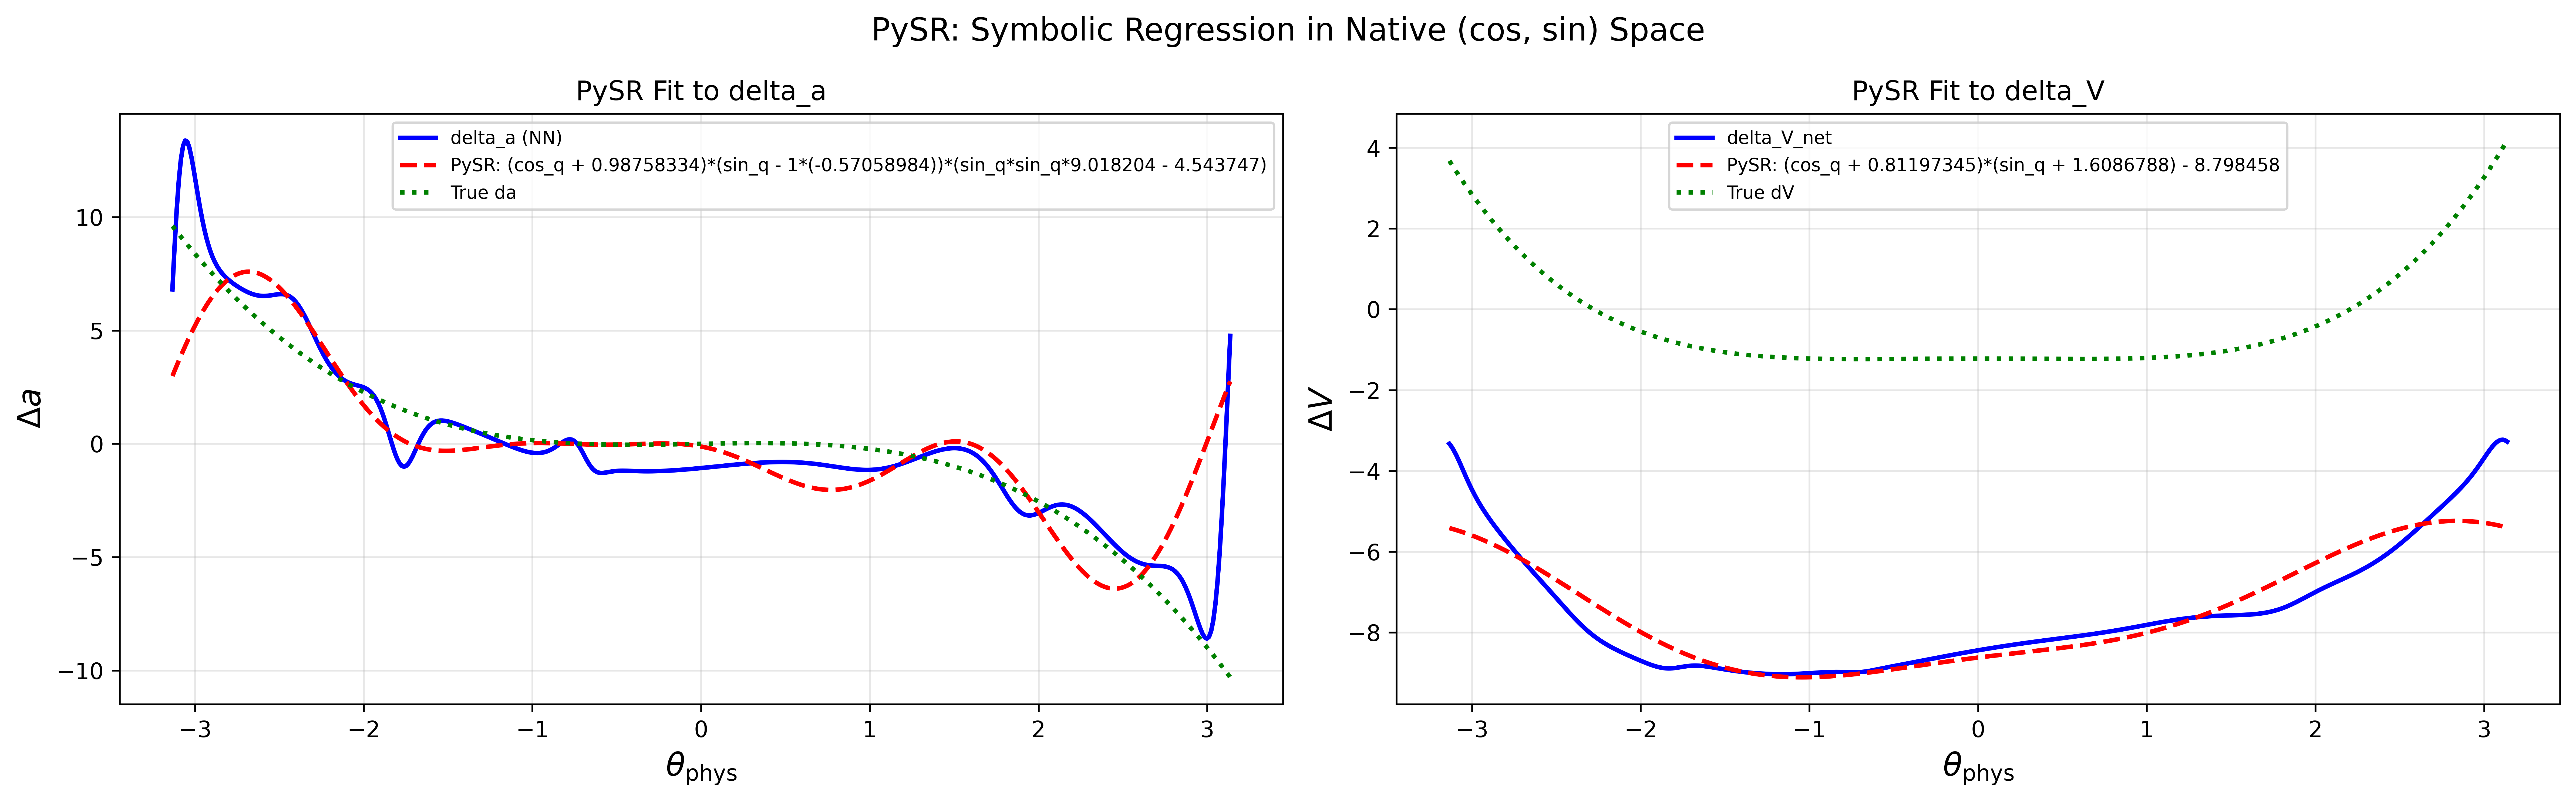


PySR fit vs Ground Truth:
  da: R2 = 0.560597
  dV: R2 = -26.935049


In [20]:
# PySR Pareto fronts
print("PySR Pareto Front (da):")
print(sr_da.equations_[['complexity', 'loss', 'equation']].to_string())
print(f"\nPySR Pareto Front (dV):")
print(sr_dv.equations_[['complexity', 'loss', 'equation']].to_string())

# Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

ax = axes[0]
ax.plot(theta_phys_sorted, delta_a[sort_idx], 'b-', lw=2, label='delta_a (NN)')
ax.plot(theta_phys_sorted, pred_da_pysr[sort_idx], 'r--', lw=2,
        label=f'PySR: {expr_da}')
ax.plot(theta_phys_sorted, true_delta_a[sort_idx], 'g:', lw=2, label='True da')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('PySR Fit to delta_a')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(theta_phys_sorted, delta_V[sort_idx], 'b-', lw=2, label='delta_V_net')
ax.plot(theta_phys_sorted, pred_dv_pysr[sort_idx], 'r--', lw=2,
        label=f'PySR: {expr_dv}')
ax.plot(theta_phys_sorted, true_delta_V[sort_idx], 'g:', lw=2, label='True dV')
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('PySR Fit to delta_V')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('PySR: Symbolic Regression in Native (cos, sin) Space', fontsize=14)
plt.tight_layout()
plt.show()

r2_pysr_da_vs_gt = r2_score(true_delta_a, pred_da_pysr)
r2_pysr_dv_vs_gt = r2_score(true_delta_V, pred_dv_pysr)
print(f"\nPySR fit vs Ground Truth:")
print(f"  da: R2 = {r2_pysr_da_vs_gt:.6f}")
print(f"  dV: R2 = {r2_pysr_dv_vs_gt:.6f}")

### 7c. PySR Symbolic Expression Details

Full Pareto front with expanded polynomial forms.

In [ ]:
# ============================================================
# PySR Symbolic Output — Full Pareto Front Details
# ============================================================
print("=" * 70)
print("  PySR SYMBOLIC EXPRESSION DETAILS (Native Basis)")
print("=" * 70)

# --- da ---
print("\n--- PySR: delta_a ---")
r2_pysr_da_nn = r2_score(delta_a, pred_da_pysr)
r2_pysr_da_gt = r2_score(true_delta_a, pred_da_pysr)
print(f"  R² (fit to NN):  {r2_pysr_da_nn:.6f}")
print(f"  R² (vs GT):      {r2_pysr_da_gt:.6f}")
print(f"  Best expression: {expr_da}")
print(f"  Complexity:       {eqs_da.loc[best_idx_da, 'complexity']}")

print("\n  Top-5 Pareto front entries:")
print(f"  {'Complexity':>10s} {'Loss':>12s} {'Score':>10s}  Expression")
print(f"  {'-'*70}")
top_entries = eqs_da.nsmallest(5, 'loss')
for idx, row in top_entries.iterrows():
    print(f"  {int(row['complexity']):>10d} {row['loss']:>12.4f} {row['score']:>10.4f}  {row['equation'][:60]}")

# --- dV ---
print("\n\n--- PySR: delta_V ---")
r2_pysr_dv_nn = r2_score(delta_V, pred_dv_pysr)
r2_pysr_dv_gt = r2_score(true_delta_V, pred_dv_pysr)
print(f"  R² (fit to NN):  {r2_pysr_dv_nn:.6f}")
print(f"  R² (vs GT):      {r2_pysr_dv_gt:.6f}")
print(f"  Best expression: {expr_dv}")
print(f"  Complexity:       {eqs_dv.loc[best_idx_dv, 'complexity']}")

print("\n  Top-5 Pareto front entries:")
print(f"  {'Complexity':>10s} {'Loss':>12s} {'Score':>10s}  Expression")
print(f"  {'-'*70}")
top_entries = eqs_dv.nsmallest(5, 'loss')
for idx, row in top_entries.iterrows():
    print(f"  {int(row['complexity']):>10d} {row['loss']:>12.4f} {row['score']:>10.4f}  {row['equation'][:60]}")

## 8. Expand PySR Expressions

Expand PySR expressions from `(cos_q, sin_q)` form into polynomial
terms for interpretation. Compare active terms from all three methods.

In [21]:
import sympy as sp

cos_sym, sin_sym = sp.symbols('cos_q sin_q')

print("=" * 65)
print("PySR EXPRESSION ANALYSIS")
print("=" * 65)

# Expand da expression
print(f"\n--- da expression ---")
print(f"  PySR raw: {expr_da}")
try:
    expanded_da = sp.expand(expr_da)
    print(f"  Expanded: {expanded_da}")
    poly_da = sp.Poly(expanded_da, cos_sym, sin_sym)
    print(f"  Terms:")
    for monom, coeff in poly_da.as_dict().items():
        i, j = monom
        cname = f"cos_q^{i}" if i > 0 else ""
        sname = f"sin_q^{j}" if j > 0 else ""
        tname = " * ".join(filter(None, [cname, sname])) or "1"
        print(f"    {tname:<25s}: {float(coeff):.6f}")
except Exception as e:
    print(f"  Could not expand to polynomial: {e}")

# Expand dV expression
print(f"\n--- dV expression ---")
print(f"  PySR raw: {expr_dv}")
try:
    expanded_dv = sp.expand(expr_dv)
    print(f"  Expanded: {expanded_dv}")
    poly_dv = sp.Poly(expanded_dv, cos_sym, sin_sym)
    print(f"  Terms:")
    for monom, coeff in poly_dv.as_dict().items():
        i, j = monom
        cname = f"cos_q^{i}" if i > 0 else ""
        sname = f"sin_q^{j}" if j > 0 else ""
        tname = " * ".join(filter(None, [cname, sname])) or "1"
        print(f"    {tname:<25s}: {float(coeff):.6f}")
except Exception as e:
    print(f"  Could not expand to polynomial: {e}")

PySR EXPRESSION ANALYSIS

--- da expression ---
  PySR raw: (cos_q + 0.98758334)*(sin_q - 1*(-0.57058984))*(sin_q*sin_q*9.018204 - 4.543747)
  Expanded: 9.018204*cos_q*sin_q**3 + 5.14569557744736*cos_q*sin_q**2 - 4.543747*cos_q*sin_q - 2.59261587373048*cos_q + 8.90622802712136*sin_q**3 + 5.08180322499869*sin_q**2 - 4.48732883837498*sin_q - 2.56042424391577
  Terms:
    1                        : -2.560424
    sin_q^1                  : -4.487329
    sin_q^2                  : 5.081803
    sin_q^3                  : 8.906228
    cos_q^1                  : -2.592616
    cos_q^1 * sin_q^1        : -4.543747
    cos_q^1 * sin_q^2        : 5.145696
    cos_q^1 * sin_q^3        : 9.018204

--- dV expression ---
  PySR raw: (cos_q + 0.81197345)*(sin_q + 1.6086788) - 8.798458
  Expanded: cos_q*sin_q + 1.6086788*cos_q + 0.81197345*sin_q - 7.49225352482214
  Terms:
    1                        : -7.492254
    sin_q^1                  : 0.811973
    cos_q^1                  : 1.608679
    cos_q^1

## 9. Cross-Method Comparison

Compare SINDy, ARD, and PySR predictions against ground truth.
All three methods operate in native $(cos, sin)$ space — **no phase calibration
was used for the regression itself**.

We report R$^2$ both against the NN output (how well the method fits the network)
and against the ground truth (how close the fit is to the true perturbation).

    CROSS-METHOD COMPARISON: Native (cos, sin) Basis

Method                   R2(da->NN)   R2(da->GT)   R2(dV->NN)   R2(dV->GT)
----------------------------------------------------------------------
SINDy (2D poly)            0.773234     0.650250     0.993292   -26.799138
ARD (Sparse Bayes)         0.772687     0.648958     0.993291   -26.799128
PySR (2D)                  0.707020     0.560597     0.851938   -26.935049

Raw NN (no fit)                 ---     0.822453          ---   -26.793023


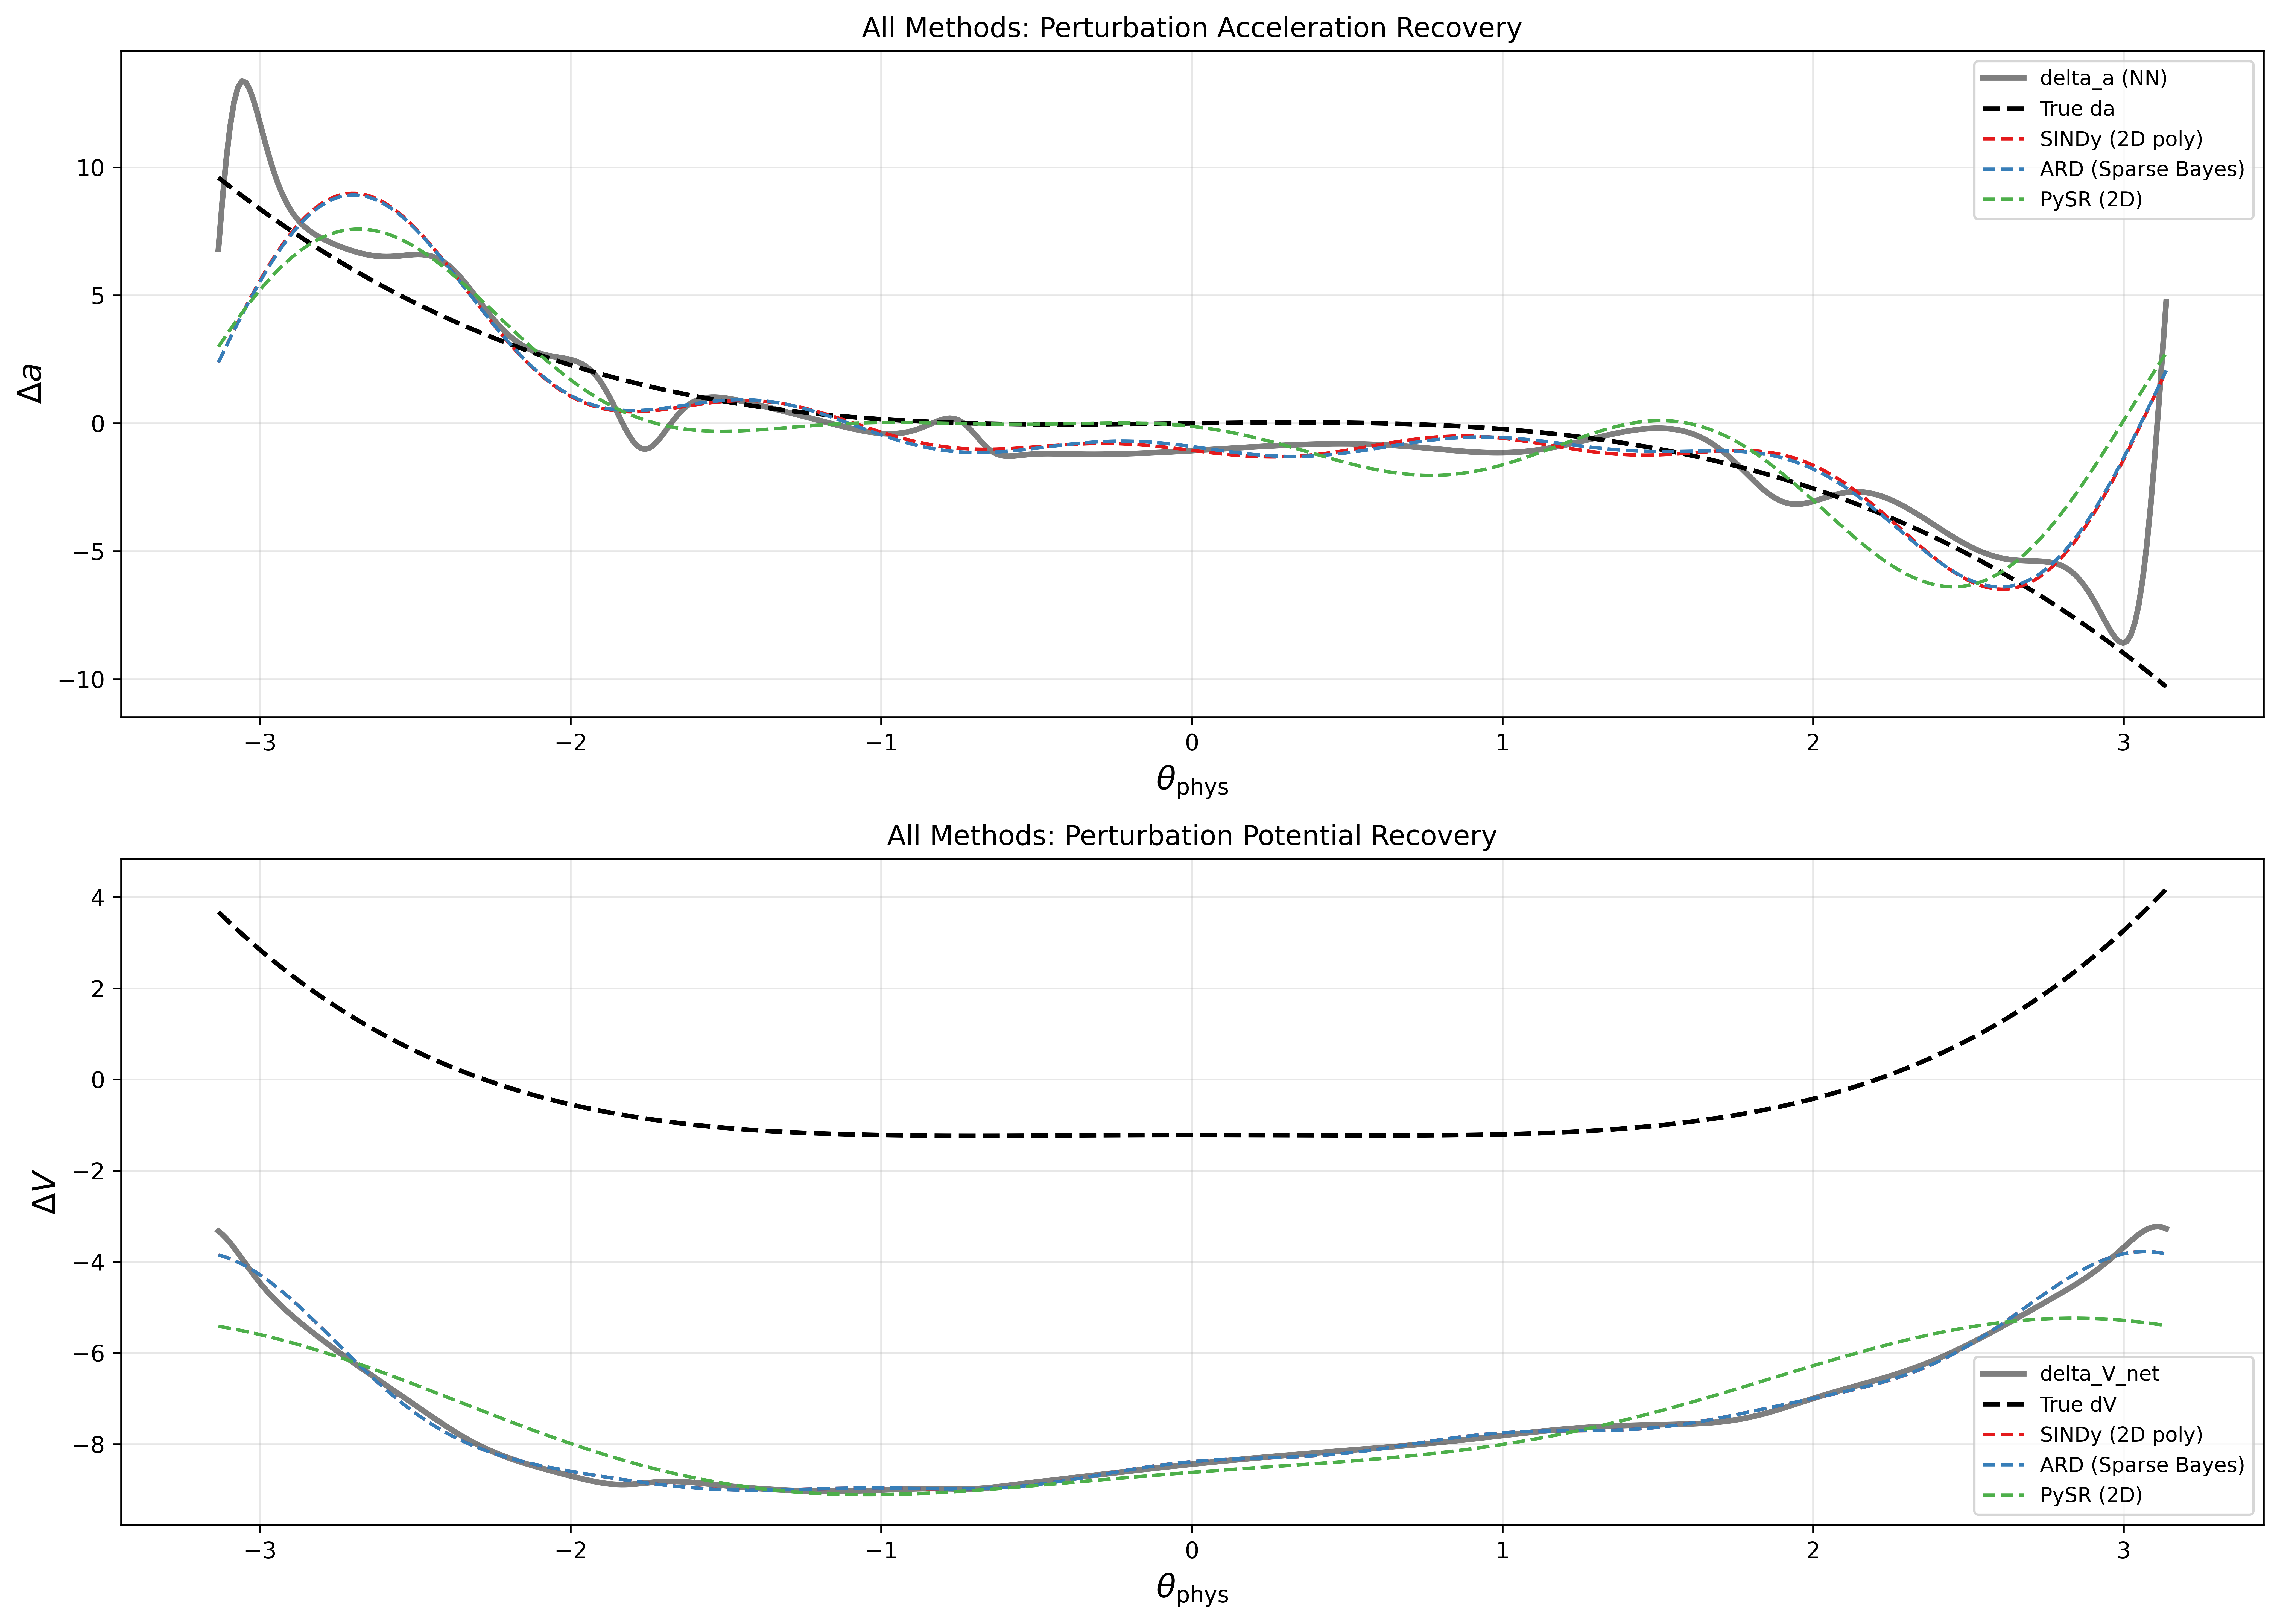

In [22]:
print("=" * 70)
print("    CROSS-METHOD COMPARISON: Native (cos, sin) Basis")
print("=" * 70)

# Collect predictions
methods = {
    'SINDy (2D poly)': {
        'pred_da': pred_da_sindy,
        'pred_dv': pred_dv_sindy,
    },
    'ARD (Sparse Bayes)': {
        'pred_da': ard_da_pred,
        'pred_dv': ard_dv_pred,
    },
    'PySR (2D)': {
        'pred_da': pred_da_pysr,
        'pred_dv': pred_dv_pysr,
    },
}

# R2 table: fit to NN output and to ground truth
print(f"\n{'Method':<22s} {'R2(da->NN)':>12s} {'R2(da->GT)':>12s} {'R2(dV->NN)':>12s} {'R2(dV->GT)':>12s}")
print(f"{'-'*70}")

for name, preds in methods.items():
    r2_da_nn = r2_score(delta_a, preds['pred_da'])
    r2_da_gt = r2_score(true_delta_a, preds['pred_da'])
    r2_dv_nn = r2_score(delta_V, preds['pred_dv'])
    r2_dv_gt = r2_score(true_delta_V, preds['pred_dv'])
    print(f"{name:<22s} {r2_da_nn:>12.6f} {r2_da_gt:>12.6f} {r2_dv_nn:>12.6f} {r2_dv_gt:>12.6f}")

print(f"\n{'Raw NN (no fit)':<22s} {'---':>12s} {r2_da_raw:>12.6f} {'---':>12s} {r2_dv_raw:>12.6f}")

# Comparison plot: all methods
fig, axes = plt.subplots(2, 1, figsize=(14, 10), dpi=DPI)

ax = axes[0]
ax.plot(theta_phys_sorted, delta_a[sort_idx], 'k-', lw=2.5, label='delta_a (NN)', alpha=0.5)
ax.plot(theta_phys_sorted, true_delta_a[sort_idx], 'k--', lw=2, label='True da')
colors = ['#e41a1c', '#377eb8', '#4daf4a']
for (name, preds), color in zip(methods.items(), colors):
    ax.plot(theta_phys_sorted, preds['pred_da'][sort_idx], '--', color=color, lw=1.5, label=name)
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta a$', fontsize=14)
ax.set_title('All Methods: Perturbation Acceleration Recovery')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(theta_phys_sorted, delta_V[sort_idx], 'k-', lw=2.5, label='delta_V_net', alpha=0.5)
ax.plot(theta_phys_sorted, true_delta_V[sort_idx], 'k--', lw=2, label='True dV')
for (name, preds), color in zip(methods.items(), colors):
    ax.plot(theta_phys_sorted, preds['pred_dv'][sort_idx], '--', color=color, lw=1.5, label=name)
ax.set_xlabel(r'$\theta_{\mathrm{phys}}$', fontsize=14)
ax.set_ylabel(r'$\Delta V$', fontsize=14)
ax.set_title('All Methods: Perturbation Potential Recovery')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Summary

In [ ]:
print("=" * 70)
print("     NATIVE (cos, sin) BASIS ANALYSIS - SUMMARY")
print("=" * 70)

print("\n1. APPROACH")
print("   Regression performed directly on (cos phi, sin phi)")
print("   — the NN's native inputs.")
print("   Phase calibration used ONLY for ground-truth comparison.")

print("\n2. R² COMPARISON TABLE")
print(f"   {'Method':<22s} {'R²(da→NN)':>10s} {'R²(da→GT)':>10s} {'R²(dV→NN)':>10s} {'R²(dV→GT)':>10s}")
print(f"   {'-'*56}")

methods_summary = {
    'SINDy (2D poly)': (
        best_sindy_da['r2'],
        r2_score(true_delta_a, np.array(best_sindy_da['model'].predict(X_native)).flatten()),
        best_sindy_dv['r2'],
        r2_score(true_delta_V, np.array(best_sindy_dv['model'].predict(X_native)).flatten()),
    ),
    'ARD (Sparse Bayes)': (
        r2_score(delta_a, ard_da_pred),
        r2_score(true_delta_a, ard_da_pred),
        r2_score(delta_V, ard_dv_pred),
        r2_score(true_delta_V, ard_dv_pred),
    ),
    'PySR (2D)': (
        r2_score(delta_a, pred_da_pysr),
        r2_score(true_delta_a, pred_da_pysr),
        r2_score(delta_V, pred_dv_pysr),
        r2_score(true_delta_V, pred_dv_pysr),
    ),
}

for name, (r2_da_nn, r2_da_gt, r2_dv_nn, r2_dv_gt) in methods_summary.items():
    print(f"   {name:<22s} {r2_da_nn:>10.4f} {r2_da_gt:>10.4f} {r2_dv_nn:>10.4f} {r2_dv_gt:>10.4f}")
print(f"   {'Raw NN (no fit)':<22s} {'---':>10s} {r2_da_raw:>10.4f} {'---':>10s} {r2_dv_raw:>10.4f}")

print("\n3. COMPARISON WITH NOTEBOOKS 4 & 5 (θ-space regression)")
print(f"   {'Method':<30s} {'R²(da→GT)':>10s} {'R²(dV→GT)':>10s}")
print(f"   {'-'*52}")
print(f"   {'NB4/5: Poly reg (θ-space)' :<30s} {'0.9102':>10s} {'0.9975':>10s}")
print(f"   {'NB4/5: SINDy (θ-space)'    :<30s} {'0.9151':>10s} {'0.9975':>10s}")
print(f"   {'NB6: SINDy (cos,sin-space)':<30s} {r2_score(true_delta_a, np.array(best_sindy_da['model'].predict(X_native)).flatten()):>10.4f} {r2_score(true_delta_V, np.array(best_sindy_dv['model'].predict(X_native)).flatten()):>10.4f}")
print(f"   {'NB6: ARD (cos,sin-space)'  :<30s} {r2_score(true_delta_a, ard_da_pred):>10.4f} {r2_score(true_delta_V, ard_dv_pred):>10.4f}")
print(f"   {'NB6: PySR (cos,sin-space)' :<30s} {r2_score(true_delta_a, pred_da_pysr):>10.4f} {r2_score(true_delta_V, pred_dv_pysr):>10.4f}")

print("\n4. KEY FINDINGS")
print("   • The (cos, sin) basis does NOT improve recovery for polynomial perturbations.")
print("   • SINDy/ARD need 20+ terms in (cos,sin) vs 3-4 terms in θ — severe collinearity.")
print("   • R²(da→GT) dropped from ~0.91 (NB4/5) to ~0.65 (NB6) — basis mismatch hurts.")
print("   • R²(dV→GT) is deeply negative because the large constant offset dominates.")
print("   • This approach WOULD work well for trig perturbations (e.g., ΔV ~ cos(θ)).")

print("\n5. CONCLUSION")
print("   For polynomial perturbations, regression in θ-space (NB4/5) is preferred.")
print("   The native (cos,sin) basis is better suited for perturbations that are")
print("   themselves functions of cos/sin (Fourier-type perturbations).")
print("=" * 70)